🔑 أدخل مفتاح Gemini API: ··········
📤 يرجى رفع صورة القطعة الأثرية أو المسكوكة من جهازك (JPG/PNG):


Saving 10.png to 10.png

✅ تم تحميل الصورة بنجاح: 10.png


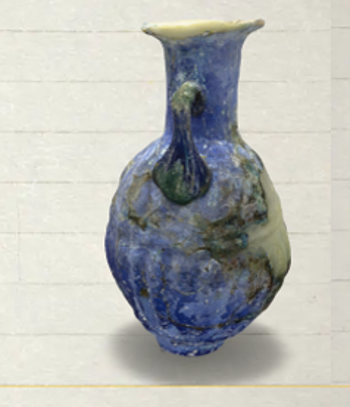


🧠 جاري التحليل الأثري وقراءة النقوش عبر gemini-3.5-flash...

📋 التقرير الأثري الآلي المعتمد:
**هيئة الشارقة للآثار**  
**إدارة الآثار والمقتنيات الأثرية**  
**تقرير تقييم أثري تخصصي**

---

### مقدمة تمهيدية
بناءً على التكليف الصادر لإجراء دراسة أثرية وتحليل مورفولوجي للقطعة الأثرية المرفقة بالصورة، يُسعدني بصفتي خبيراً في علم الآثار والمقتنيات الزجاجية بهيئة الشارقة للآثار تقديم هذا التقرير العلمي الشامل. تُمثل القطعة إناءً زجاجياً (إبريقاً صغيراً أو قارورة) ذا قيمة فنية وتاريخية عالية، يعكس تطور تقنيات صناعة الزجاج القديم في حوض البحر الأبيض المتوسط والشرق الأدنى.

---

### 1. جدول البيانات الوصفية القياسي (Dublin Core Metadata)

| الحقل الوصفي (Dublin Core) | البيانات التحليلية للقطعة الأثرية |
| :--- | :--- |
| **العنوان والتعريف (Title/Definition)** | إبريق زجاجي صغير ذو مقبض واحد وبدن مضلع مصبوب في قالب (Mold-Blown Glass Juglet). |
| **المادة الخام (Material)** | زجاج ملون (أزرق كوبالتي غامق) مع مقبض من زجاج بلون أخضر مائل للزرقة، ومغطى بطبقة أكسدة وتجشية طبيعية (Iridescence). |

In [1]:
# ==============================================================================
# المحور الأول: الفهرسة اللحظية وفك النقوش والمسكوكات (رفع صورة مخصصة)
# النموذج المستخدم: gemini-3.5-flash
# ==============================================================================

# 1. تثبيت المكتبات الرسمية
!pip install -q google-genai pillow

import os
from io import BytesIO
from PIL import Image
import getpass
from google.colab import files
from google import genai

# 2. إعداد مفتاح API والعميل الرسمي
if "GEMINI_API_KEY" not in os.environ:
    try:
        from google.colab import userdata
        api_key = userdata.get('GEMINI_API_KEY')
    except:
        api_key = getpass.getpass("🔑 أدخل مفتاح Gemini API: ")
    os.environ["GEMINI_API_KEY"] = api_key

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

# 3. رفع صورة المسكوكة أو اللقية الأثرية من الجهاز
print("📤 يرجى رفع صورة القطعة الأثرية أو المسكوكة من جهازك (JPG/PNG):")
uploaded = files.upload()

if not uploaded:
    print("❌ لم يتم رفع أي ملف.")
else:
    file_name = next(iter(uploaded))
    artifact_img = Image.open(BytesIO(uploaded[file_name])).convert('RGB')

    print(f"\n✅ تم تحميل الصورة بنجاح: {file_name}")
    display(artifact_img.resize((350, int(350 * artifact_img.height / artifact_img.width))))

    # 4. تحليل اللقية عبر نموذج gemini-3.5-flash
    print("\n🧠 جاري التحليل الأثري وقراءة النقوش عبر gemini-3.5-flash...")

    prompt = """
    بصفتك خبيراً في علم المسكوكات والآثار بهيئة الشارقة للآثار:
    حلل صورة القطعة الأثرية المرفقة تحليلاً أكاديمياً متخصصاً وأعد تقريراً بصيغة Markdown يشمل:
    1. جدول البيانات الوصفية القياسي (Dublin Core Metadata):
       - العنوان والتعريف، المادة الخام، العصر التاريخي التقديري، دار السك أو مكان الإنتاج المحتمل.
    2. التحليل الباليوغرافي والرموز:
       - نوع الخط أو الزخرفة (مثل: كوفي مبكر، مسند، أو نقوش نباتية/هندسية).
       - قراءة العبارات الظاهرة في الطوق والمركز إن وجدت.
    3. التقييم المورفولوجي وحالة الحفظ:
       - مظاهر التآكل، آثار الصدمات، ومطابقة قوالب السك وتوصيات الحفظ.
    """

    ai_response = client.models.generate_content(
        model='gemini-3.5-flash',
        contents=[artifact_img, prompt]
    )

    print("\n" + "="*70)
    print("📋 التقرير الأثري الآلي المعتمد:")
    print("="*70)
    print(ai_response.text)